In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.datasets as tds
import torchvision.utils as tu

import matplotlib.pyplot as plt

In [2]:
mnist_train = tds.FashionMNIST(
    root='datasets',
    download=True,
    train=True,
)

mnist_eval = tds.FashionMNIST(
    root='datasets',
    download=True,
    train=False,
)


In [3]:
class MnistBinary:
    def __init__(self, mnist: tds.MNIST, label0: int, label1: int):
        d0 = mnist.data[mnist.targets == label0]
        d1 = mnist.data[mnist.targets == label1]

        l0 = torch.zeros(len(d0))
        l1 = torch.ones(len(d1))
        
        self.data = torch.cat((d0, d1))
        self.targets = torch.cat((l0, l1))

    def __getitem__(self, index: int):
        return (self.data[index], self.targets[index])

    def __len__(self):
        return len(self.data)

    def random_grid(self, sz: int):
        samples_ix = torch.randint(low=0, high=len(self.data) - 1, size=(sz,))
        samples = self.data[samples_ix]
        samples = samples[:, None, ...]
        grid = tu.make_grid(samples)
        return grid.permute(1, 2, 0)        

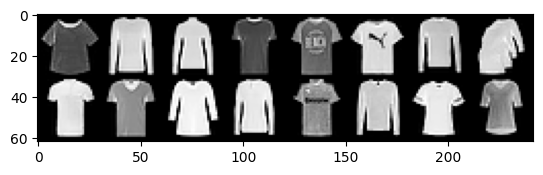

In [4]:
train = MnistBinary(mnist_train, 0, 2)
val = MnistBinary(mnist_eval, 0, 2)
plt.imshow(val.random_grid(16))

In [5]:
batchsize = 32

train_loader = tud.DataLoader(train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(val, batch_size=batchsize, shuffle=True)

In [6]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.view(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = F.sigmoid(x)
        return x
        

In [7]:
testmodel = MyNn(28 * 28, 1)
test = train[0][0].unsqueeze(0).float()
testmodel(test)

tensor([[1.]], grad_fn=<SigmoidBackward0>)

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyNn(28 * 28, 1, hidden_sz=32).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.L1Loss()
epochs = 10

for epoch in range(epochs):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 1))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 1))
            losses.append(loss)
    print("Val loss {}".format(torch.Tensor(losses).mean()))

Val loss 0.27978241443634033
Val loss 0.27293381094932556
Val loss 0.2749350965023041
Val loss 0.2754628360271454
Val loss 0.2804092466831207
Val loss 0.27120813727378845
Val loss 0.27033013105392456
Val loss 0.2737303078174591
Val loss 0.2707250714302063
Val loss 0.27654287219047546


In [9]:
total = len(val)
correct = 0
with torch.no_grad():
    for image, target in val:
        pred = model(image.float().to(device))
        if (pred.round() == target):
            correct += 1
            
    print("{:.2f}% correct".format(100*correct/total))

94.80% correct
